In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

#CNN architechture adapted from in class example as a starting architecture
class CNN(nn.Module):
    def __init__(self, device, dataloader, num_classes=3, dropout_cnn=0.25, dropout_class=0.3, kernel_size=3, max_pool=2, padding=1):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(max_pool),
            nn.Dropout2d(p=dropout_cnn),
            nn.MaxPool2d(max_pool),
            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=padding),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(p=dropout_cnn),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_class),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_class),
            nn.Linear(256, num_classes),

        )
        self.device = device
        self.dataloader = dataloader

    def train_one_epoch(self, optimizer, criterion):
        self.cnn.train()
        total_loss = 0.0
        for i, l in self.dataloader:
            i, l = i.to(self.device), l.to(self.device).long()
            optimizer.zero_grad()
            loss = criterion(self.forward(i), l)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * i.size(0)
        return total_loss / len(self.dataloader.dataset)

    def forward(self, x):
        cnn_output = self.cnn(x)
        output= self.classifier(cnn_output)
        return output

    def run_experiment(self, num_epochs, lr=1e-3):

        criterion = nn.CrossEntropyLoss() #this loss converts the real values into probabilites in it first
        optimizer = optim.Adam(self.parameters(), lr=lr)
        history = {"train_loss": [], "test_loss": [], "test_acc": []}

        for epoch in range(1, num_epochs + 1):
            print('Training epoch: ', epoch)
            tr_loss = self.train_one_epoch(optimizer, criterion)
            print("Epoch " + str(epoch) + ' loss: ' + str(tr_loss))
            # te_loss, te_acc  = evaluate(model, X_test, y_test, criterion)
            history["train_loss"].append(tr_loss)
            # history["test_loss"].append(te_loss)
            # history["test_acc"].append(te_acc)
            if epoch % 10 == 0:
                print(f"  Epoch {epoch:3d} | train loss {tr_loss:.4f} ") #| "
                    #   f"test loss {te_loss:.4f} | test acc {te_acc:.3f}")
        return history

In [16]:
class FCN(nn.Module):
    def __init__ (self, criterion, dataloader, lr=1e-3):
      super().__init__()
      self.fcn = nn.Sequential(
          nn.Flatten(),
          nn.Linear(3 * 224 * 224, 256),
          nn.BatchNorm1d(256),
          nn.ReLU(),
          nn.Linear(256, 128),
          nn.BatchNorm1d(128),
          nn.ReLU(),
          nn.Linear(128, 7),
      )
      self.criterion=criterion
      self.optimizer = optim.Adam(self.fcn.parameters(), lr=lr)
      self.dataloader = dataloader
    def train(self, epochs):
      history = {"train_loss": [], "test_loss": [], "test_acc": []}
      for epoch in range(1, epochs + 1):
        self.fcn.train()
        total_loss = 0
        for images, labels in dataloader:

          probs = self.fcn(images).squeeze(1)
          loss  = self.criterion(probs, labels)

          self.optimizer.zero_grad()
          loss.backward()
          self.optimizer.step()

          total_loss += loss.item()
        print("Epoch " + str(epoch) + ' loss: ' + str(total_loss))
        history["train_loss"].append(total_loss)
      avg_loss = total_loss / len(dataloader)
      print(f"Epoch {epoch:>2}/{epochs}  |  Loss = {avg_loss:.4f}")
      return history, avg_loss

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Subset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
torch.manual_seed(32)
np.random.seed(32)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") #this ensures that the code runs on GPUs if available
print(f"Device: {DEVICE}\n")

Device: cuda



In [6]:
#loading in the data:
images = torch.tensor(np.load("/content/drive/MyDrive/final_data/train_images.npy"), dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
labels = torch.tensor(np.load("/content/drive/MyDrive/final_data/train_labels.npy"))

dataset = TensorDataset(images, labels)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Images loaded succesfully: ", images.shape)
print("Labels loaded succesfully: ", labels.shape)

EPOCHS = 100

Images loaded succesfully:  torch.Size([3500, 3, 224, 224])
Labels loaded succesfully:  torch.Size([3500])


In [18]:
criterion = nn.CrossEntropyLoss()

fcn = FCN(criterion, dataloader, lr=1e-3)
hist_fully, _ = fcn.train(EPOCHS)

Epoch 1 loss: 63.05877035856247
Epoch 2 loss: 51.84445536136627
Epoch 3 loss: 49.64164763689041
Epoch 4 loss: 47.5773087143898
Epoch 5 loss: 44.797588527202606
Epoch 6 loss: 42.14455461502075
Epoch 7 loss: 40.689473032951355
Epoch 8 loss: 36.794390708208084
Epoch 9 loss: 34.754042625427246
Epoch 10 loss: 31.28343141078949
Epoch 11 loss: 28.324877500534058
Epoch 12 loss: 26.698029845952988
Epoch 13 loss: 23.990583896636963
Epoch 14 loss: 21.342275321483612
Epoch 15 loss: 19.422384172677994
Epoch 16 loss: 18.122968047857285
Epoch 17 loss: 15.49879865348339
Epoch 18 loss: 15.149628169834614
Epoch 19 loss: 12.445248581469059
Epoch 20 loss: 10.807317405939102
Epoch 21 loss: 9.282727256417274
Epoch 22 loss: 9.221864502876997
Epoch 23 loss: 8.430596202611923
Epoch 24 loss: 6.0271559320390224
Epoch 25 loss: 5.78779954649508
Epoch 26 loss: 7.471305925399065
Epoch 27 loss: 7.962157294154167
Epoch 28 loss: 7.535152040421963
Epoch 29 loss: 5.528606973588467
Epoch 30 loss: 5.048469312489033
Epoch 3

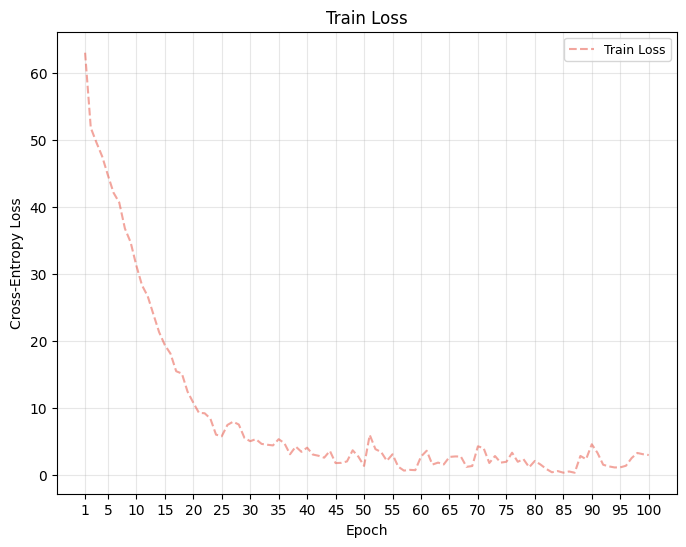

In [22]:
epochs  = range(1, EPOCHS + 1)

colors = ["#e74c3c", "#2ecc71"]

# Loss curves
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(epochs, hist_fully["train_loss"], label="Train Loss", color=colors[0], linestyle="--", alpha=0.5)
# ax.plot(epochs, hist_base["test_loss"],  label="Test Loss", color=colors[1], linestyle="-")
ax.set_title("Train Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks([1] + list(range(5, EPOCHS+1, 5)))
plt.show()

In [20]:
cnn = CNN(device=DEVICE, dataloader=dataloader, num_classes=7).to(DEVICE)
hist_base  = cnn.run_experiment(EPOCHS, lr=1e-4)

Training epoch:  1
Epoch 1 loss: 1.2129363495962961
Training epoch:  2
Epoch 2 loss: 1.1142434829984393
Training epoch:  3
Epoch 3 loss: 1.0765448565483093
Training epoch:  4
Epoch 4 loss: 1.0459875207628522
Training epoch:  5
Epoch 5 loss: 1.0096738662719726
Training epoch:  6
Epoch 6 loss: 0.9918826981272016
Training epoch:  7
Epoch 7 loss: 0.9759535970687866
Training epoch:  8
Epoch 8 loss: 0.9572441299302238
Training epoch:  9
Epoch 9 loss: 0.9451219647271293
Training epoch:  10
Epoch 10 loss: 0.9410652378627232
  Epoch  10 | train loss 0.9411 
Training epoch:  11
Epoch 11 loss: 0.931431756223951
Training epoch:  12
Epoch 12 loss: 0.9211835483823504
Training epoch:  13
Epoch 13 loss: 0.9057926693643843
Training epoch:  14
Epoch 14 loss: 0.9019076700210571
Training epoch:  15
Epoch 15 loss: 0.8800686585562569
Training epoch:  16
Epoch 16 loss: 0.8800694347109114
Training epoch:  17
Epoch 17 loss: 0.8590770198958261
Training epoch:  18
Epoch 18 loss: 0.8484342391150338
Training epoch

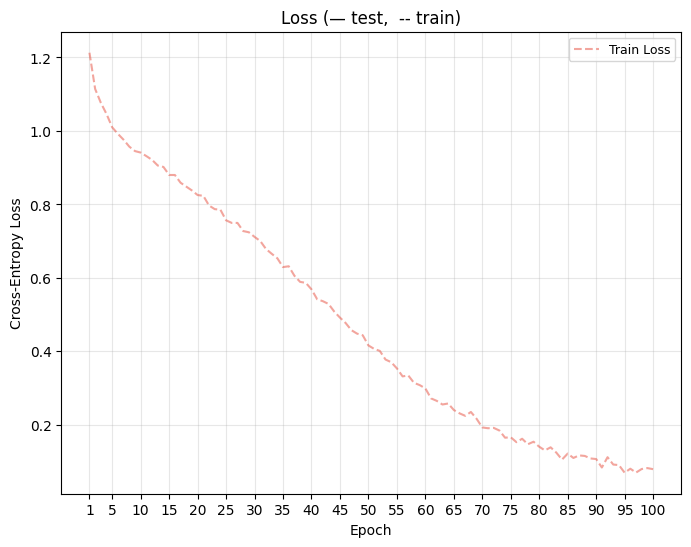

In [21]:
epochs  = range(1, EPOCHS + 1)

colors = ["#e74c3c", "#2ecc71"]

# Loss curves
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(epochs, hist_base["train_loss"], label="Train Loss", color=colors[0], linestyle="--", alpha=0.5)
# ax.plot(epochs, hist_base["test_loss"],  label="Test Loss", color=colors[1], linestyle="-")
ax.set_title("Train Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks([1] + list(range(5, EPOCHS+1, 5)))
plt.show()